# Notebook 07 — Adaptive Hedge Ratio via Kalman Filter

**Adaptive Pair Trading using Cointegration, Volatility and ML Diagnostics**  
**Author:** Ayush Arora (MQMS2404)

---

## Why this notebook is the core of the project

All prior notebooks used a **static OLS hedge ratio** (β = 0.245) estimated once on the full
10-year sample. This creates two problems:

1. **Look-ahead bias**: the hedge ratio uses future data at every historical point  
2. **Structural drift**: the TATASTEEL / HINDALCO relationship shifts with commodity cycles,
   corporate actions, and sectoral rotations — a fixed β accumulates basis risk over time

The **Kalman Filter** solves both problems simultaneously.  
It estimates a **time-varying** β_t at each date using only data up to that date,
and it updates the estimate continuously as new observations arrive.

### State-Space Model

```
Observation:   A_t = α_t + β_t · B_t + ε_t,     ε_t ~ N(0, R)
State dynamics: [α_t, β_t]ᵀ = [α_{t-1}, β_{t-1}]ᵀ + w_t,   w_t ~ N(0, Q)
```

The state vector `[α_t, β_t]` follows a **random walk** — sensible for slowly-drifting
financial relationships.  δ (process noise) controls the speed of adaptation.

### Comparison
- Section A: Kalman Filter vs OLS hedge ratio over time  
- Section B: Adaptive spread vs static spread — stationarity comparison  
- Section C: Full backtest with adaptive hedge ratio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from config import (
    PRICES_FILE, ROLL_WINDOW, ROLL_MIN_PERIODS, rolling_zscore,
    KF_DELTA, KF_INIT_P, kalman_hedge,
    ENTRY_Z, EXIT_Z,
    COST_BPS_ROUND_TRIP, COST_BPS_ROUND_TRIP_LEVELS,
    pair_backtest, sharpe_ratio, max_drawdown,
)

COST_LEVELS = list(COST_BPS_ROUND_TRIP_LEVELS)   # (10, 30, 60) bps round trip
BASE_COST   = COST_BPS_ROUND_TRIP
print('Loaded. Kalman delta =', KF_DELTA, '| cost levels', COST_LEVELS, 'bps round trip')

Loaded. Kalman delta = 0.0001 | cost levels [10, 30, 60] bps round trip


## Section A: Kalman Filter — Adaptive Hedge Ratio

In [2]:
prices = pd.read_csv(PRICES_FILE, index_col=0, parse_dates=True)
A = prices['TATASTEEL.NS']
B = prices['HINDALCO.NS']

# ── Static OLS benchmark (A on B) ──────────────────────────────────────────
ols_model = sm.OLS(A, sm.add_constant(B)).fit()
beta_ols  = ols_model.params.iloc[1]
alpha_ols = ols_model.params.iloc[0]

print(f"Static OLS (TATASTEEL on HINDALCO): alpha = {alpha_ols:.4f}, beta = {beta_ols:.4f}")
print("Note: NB09/NB10 read pairs from top_pairs.csv, which orients this pair the "
      "other way (HINDALCO on TATASTEEL). NB07 keeps the NB00-02 orientation.")

Static OLS (TATASTEEL on HINDALCO): alpha = -4.6671, beta = 0.2452
Note: NB09/NB10 read pairs from top_pairs.csv, which orients this pair the other way (HINDALCO on TATASTEEL). NB07 keeps the NB00-02 orientation.


In [3]:
# Kalman filter is config.kalman_hedge — the SAME implementation NB10 uses.
# State = [alpha_t, beta_t] random walk; R estimated online; delta = KF_DELTA.
kf_alpha, kf_beta, kf_spread = kalman_hedge(A, B)      # delta=KF_DELTA, init_p=KF_INIT_P

print(f"Kalman beta range:  [{kf_beta.min():.4f}, {kf_beta.max():.4f}]")
print(f"Kalman beta final:  {kf_beta.iloc[-1]:.4f}   (OLS static: {beta_ols:.4f})")
print(f"Kalman beta std:    {kf_beta.iloc[ROLL_MIN_PERIODS:].std():.4f}  "
      f"(after {ROLL_MIN_PERIODS}-day warm-up)")

Kalman beta range:  [0.1163, 0.2985]
Kalman beta final:  0.2112   (OLS static: 0.2452)
Kalman beta std:    0.0325  (after 60-day warm-up)


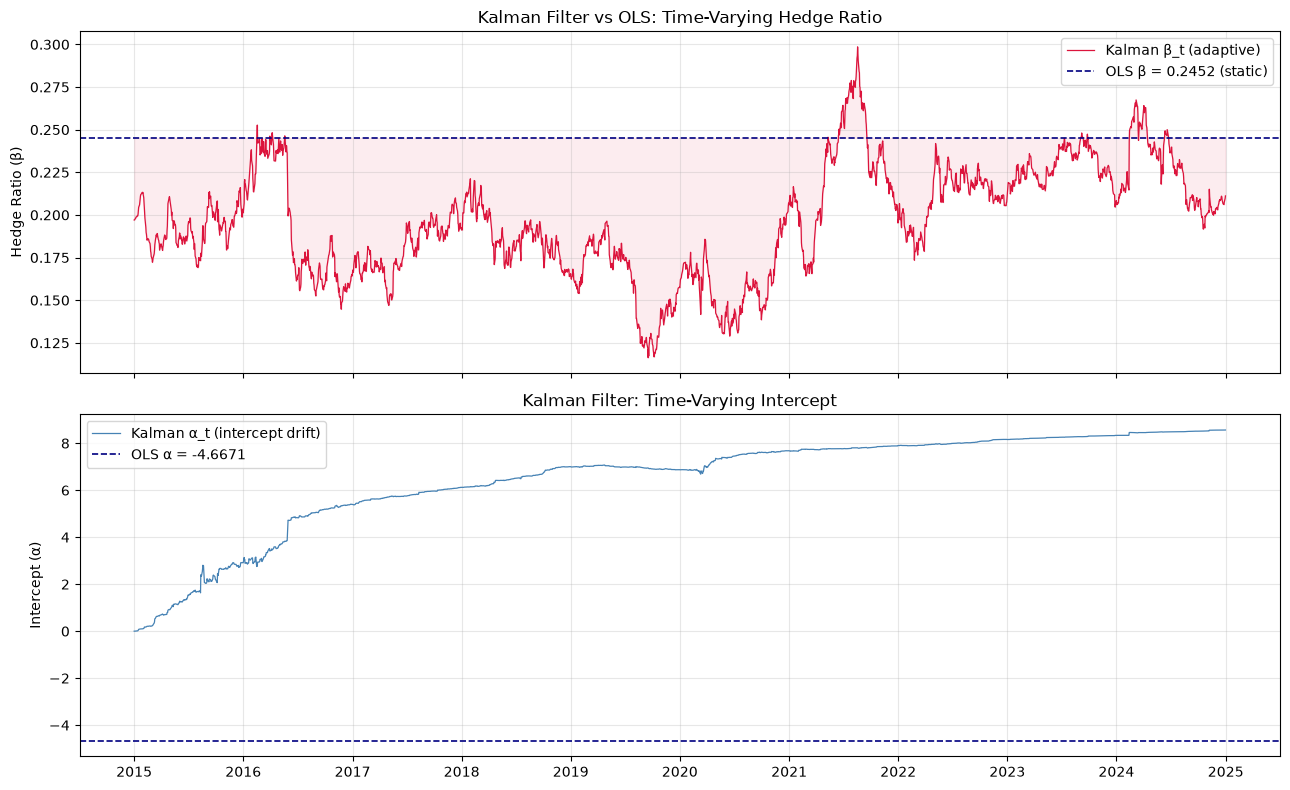

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(kf_beta, color='crimson',   linewidth=0.9, label='Kalman β_t (adaptive)')
axes[0].axhline(beta_ols, color='navy', linewidth=1.2, linestyle='--', label=f'OLS β = {beta_ols:.4f} (static)')
axes[0].fill_between(kf_beta.index, kf_beta, beta_ols, alpha=0.08, color='crimson')
axes[0].set_ylabel('Hedge Ratio (β)')
axes[0].set_title('Kalman Filter vs OLS: Time-Varying Hedge Ratio')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(kf_alpha, color='steelblue', linewidth=0.9, label='Kalman α_t (intercept drift)')
axes[1].axhline(alpha_ols, color='navy', linewidth=1.2, linestyle='--', label=f'OLS α = {alpha_ols:.4f}')
axes[1].set_ylabel('Intercept (α)')
axes[1].set_title('Kalman Filter: Time-Varying Intercept')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Section B: Adaptive Spread vs Static Spread — Stationarity Comparison

The Kalman spread is the **innovation sequence** e_t from the filter:  
`e_t = A_t − α_t − β_t · B_t`

Because the filter continuously adjusts β_t, the innovation should be more stationary
than the residual from a fixed-β model.  We verify this with ADF tests and visual inspection.

C:\Users\arora\AppData\Local\Temp\ipykernel_17068\3295286059.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_static = adfuller(static_spread.dropna())
C:\Users\arora\AppData\Local\Temp\ipykernel_17068\3295286059.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_kf     = adfuller(kf_spread_s.dropna())


Spread type                   ADF statistic     p-value   Stationary?
--------------------------------------------------------------------
Static OLS (fixed beta)             -4.6353    0.000111           Yes
Kalman Filter (adaptive)            -9.8071    0.000000           Yes


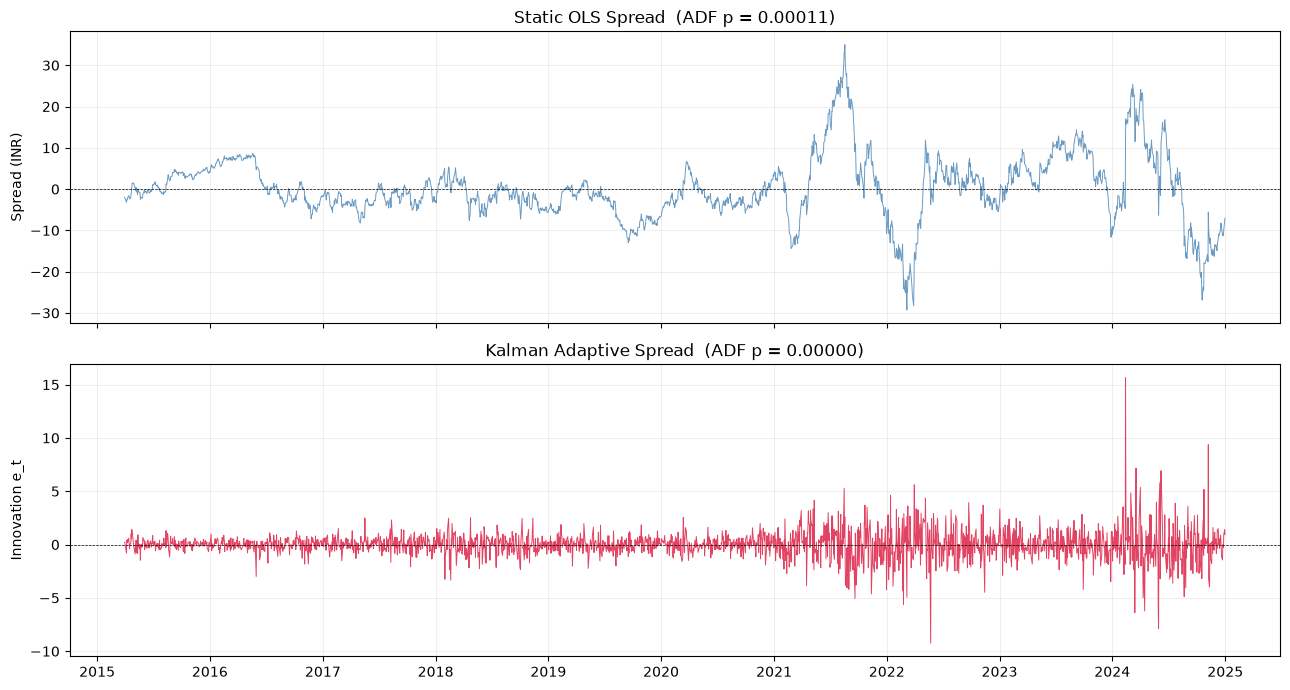

In [5]:
static_spread = (A - beta_ols * B - alpha_ols).iloc[ROLL_MIN_PERIODS:]   # fixed-beta residual
kf_spread_s   = kf_spread.iloc[ROLL_MIN_PERIODS:]                        # Kalman innovations

adf_static = adfuller(static_spread.dropna())
adf_kf     = adfuller(kf_spread_s.dropna())

print(f"{'Spread type':<28} {'ADF statistic':>14}  {'p-value':>10}  {'Stationary?':>12}")
print("-" * 68)
print(f"{'Static OLS (fixed beta)':<28} {adf_static[0]:>14.4f}  {adf_static[1]:>10.6f}  {'Yes' if adf_static[1]<0.05 else 'No':>12}")
print(f"{'Kalman Filter (adaptive)':<28} {adf_kf[0]:>14.4f}  {adf_kf[1]:>10.6f}  {'Yes' if adf_kf[1]<0.05 else 'No':>12}")

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(static_spread, color='steelblue', linewidth=0.7, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title(f'Static OLS Spread  (ADF p = {adf_static[1]:.5f})')
axes[0].set_ylabel('Spread (INR)')
axes[0].grid(alpha=0.2)

axes[1].plot(kf_spread_s, color='crimson', linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title(f'Kalman Adaptive Spread  (ADF p = {adf_kf[1]:.5f})')
axes[1].set_ylabel('Innovation e_t')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('kalman_vs_static_spread.png', dpi=150, bbox_inches='tight')
plt.show()

## Section C: Adaptive Backtest — Static OLS vs Kalman Hedge

Both hedges are run through the **same** engine, `config.pair_backtest`:

- P&L is a **return on deployed capital** (gross exposure `price_A + |β|·price_B`),
  bounded below by −100% — not the old `spread.diff() / mean|spread|` that had no
  capital base
- Sharpe (`config.sharpe_ratio`) is over the **full** daily series, flat days included
- Costs swept at **10 / 30 / 60 bps** round trip, all reported

The only thing that differs between the two runs is the hedge ratio: a constant
`beta_ols` vs the time-varying `kf_beta`. The Z-score is `config.rolling_zscore`
either way — on the static OLS residual, or on the Kalman innovation.

In [6]:
# ── Z-scores: the ONE definition (config.rolling_zscore, 252/60) ───────────
static_spread_full = A - beta_ols * B - alpha_ols
static_zscore = rolling_zscore(static_spread_full)     # on the fixed-beta residual
kf_zscore     = rolling_zscore(kf_spread)              # on the Kalman innovation

print(f"Static Z-score valid rows: {static_zscore.dropna().shape[0]}")
print(f"Kalman Z-score valid rows: {kf_zscore.dropna().shape[0]}")

Static Z-score valid rows: 2408
Kalman Z-score valid rows: 2408


In [7]:
# Run both hedges through config.pair_backtest at every cost level.
# Static: scalar beta_ols on the static residual Z-score.
# Kalman: Series kf_beta (lagged inside pair_backtest) on the innovation Z-score.
bt = {}   # bt[('static'|'kalman', cost)] -> DataFrame from pair_backtest
for cost in COST_LEVELS:
    bt[('static', cost)] = pair_backtest(A, B, beta_ols, static_zscore,
                                         cost_bps_round_trip=cost)
    bt[('kalman', cost)] = pair_backtest(A, B, kf_beta, kf_zscore,
                                         cost_bps_round_trip=cost)

ret_static = bt[('static', BASE_COST)]['ret']
ret_kalman = bt[('kalman', BASE_COST)]['ret']
cum_static = (1 + ret_static).cumprod() - 1
cum_kalman = (1 + ret_kalman).cumprod() - 1

print(f"Cumulative return on capital @ {BASE_COST} bps round trip (2015-2024, IN-SAMPLE):")
print(f"  Static OLS hedge    : {cum_static.iloc[-1]*100:+.2f}%")
print(f"  Kalman adaptive hedge: {cum_kalman.iloc[-1]*100:+.2f}%")

Cumulative return on capital @ 30 bps round trip (2015-2024, IN-SAMPLE):
  Static OLS hedge    : +98.24%
  Kalman adaptive hedge: -31.07%


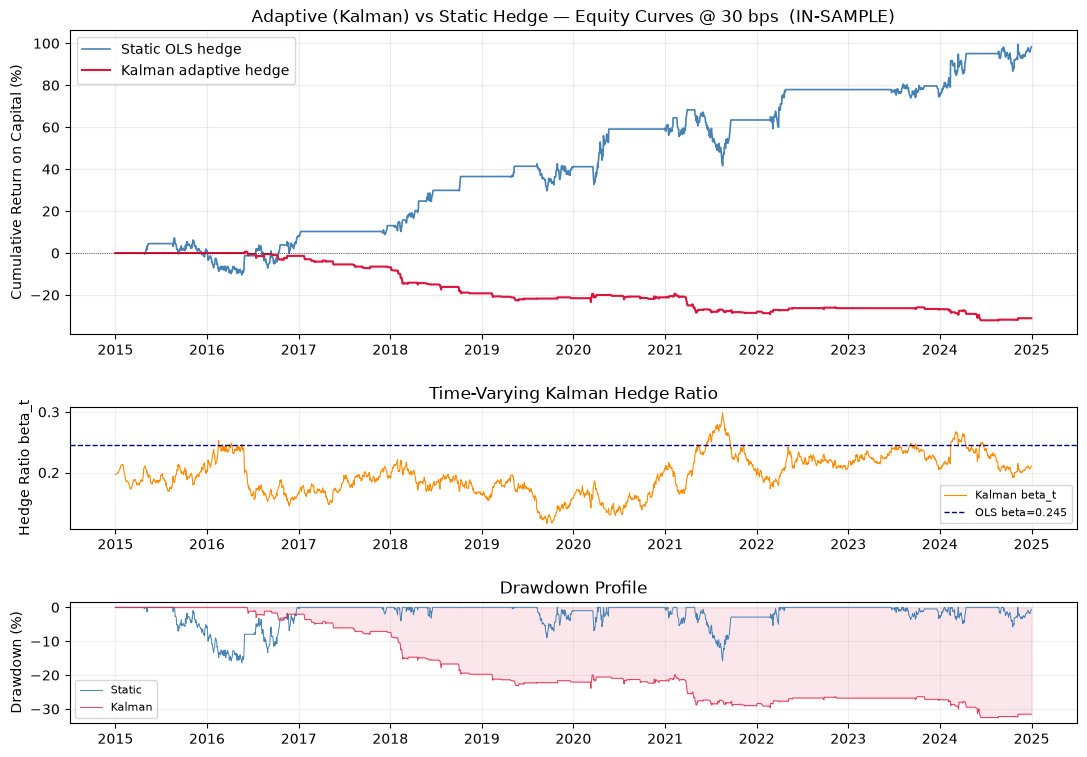

In [8]:
fig = plt.figure(figsize=(13, 9))
gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1.2, 1.2], hspace=0.4)

# ── Equity curves (return on capital, bounded) ────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(cum_static * 100, color='steelblue', linewidth=1.2, label='Static OLS hedge')
ax1.plot(cum_kalman * 100, color='crimson',   linewidth=1.5, label='Kalman adaptive hedge')
ax1.axhline(0, color='black', linewidth=0.5, linestyle=':')
ax1.set_ylabel('Cumulative Return on Capital (%)')
ax1.set_title(f'Adaptive (Kalman) vs Static Hedge — Equity Curves @ {BASE_COST} bps  (IN-SAMPLE)')
ax1.legend(); ax1.grid(alpha=0.25)

# ── Kalman beta evolution ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(kf_beta, color='darkorange', linewidth=0.8, label='Kalman beta_t')
ax2.axhline(beta_ols, color='navy', linewidth=1.0, linestyle='--', label=f'OLS beta={beta_ols:.3f}')
ax2.set_ylabel('Hedge Ratio beta_t')
ax2.set_title('Time-Varying Kalman Hedge Ratio')
ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

# ── Drawdown comparison ─────────────────────────────────────────────────
def dd_pct(ret):
    c = (1 + ret).cumprod()
    return (c - c.cummax()) / c.cummax() * 100
ax3 = fig.add_subplot(gs[2])
ax3.plot(dd_pct(ret_static), color='steelblue', linewidth=0.7, label='Static')
ax3.plot(dd_pct(ret_kalman), color='crimson',   linewidth=0.7, label='Kalman', alpha=0.8)
ax3.fill_between(dd_pct(ret_kalman).index, dd_pct(ret_kalman), 0, alpha=0.1, color='crimson')
ax3.set_ylabel('Drawdown (%)'); ax3.set_title('Drawdown Profile')
ax3.legend(fontsize=8); ax3.grid(alpha=0.2)

plt.savefig('kalman_vs_static_equity.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
def report(bt_df, label):
    r   = bt_df['ret']
    pos = bt_df['pos']
    ann_r = r.mean() * 252
    mdd   = max_drawdown(r)                       # % (guarded; raises if equity <= 0)
    act   = r[r != 0]
    trades = int(((pos != 0) & (pos.shift(1).fillna(0) == 0)).sum())
    return pd.Series({
        'Ann Return %':  round(ann_r * 100, 2),
        'Ann Vol %':     round(r.std() * np.sqrt(252) * 100, 2),
        'Sharpe':        round(sharpe_ratio(r), 3),
        'Max DD %':      round(mdd, 2),
        'Time in Mkt %': round(bt_df['in_market'].mean() * 100, 1),
        'Hit %':         round((act > 0).mean() * 100, 1) if len(act) else np.nan,
        'Trades':        trades,
    }, name=label)

for cost in COST_LEVELS:
    summary = pd.DataFrame([
        report(bt[('static', cost)], 'Static OLS hedge'),
        report(bt[('kalman', cost)], 'Kalman adaptive hedge'),
    ]).T
    print('=' * 60)
    print(f'  STATIC vs KALMAN  @ {cost} bps round trip   (IN-SAMPLE, 2015-2024)')
    print('=' * 60)
    print(summary.to_string())
    print()

print("Reminder: in-sample, single pair (TATASTEEL/HINDALCO). NB09 is the "
      "out-of-sample test; it uses a static OLS beta per window.")

  STATIC vs KALMAN  @ 10 bps round trip   (IN-SAMPLE, 2015-2024)
               Static OLS hedge  Kalman adaptive hedge
Ann Return %              7.970                 -1.040
Ann Vol %                10.560                  4.230
Sharpe                    0.755                 -0.246
Max DD %                -16.470                -16.700
Time in Mkt %            39.600                  8.600
Hit %                    50.200                 29.900
Trades                   21.000                131.000

  STATIC vs KALMAN  @ 30 bps round trip   (IN-SAMPLE, 2015-2024)
               Static OLS hedge  Kalman adaptive hedge
Ann Return %              7.540                 -3.720
Ann Vol %                10.520                  4.110
Sharpe                    0.717                 -0.904
Max DD %                -16.470                -32.620
Time in Mkt %            39.600                  8.600
Hit %                    50.100                 27.600
Trades                   21.000             

In [10]:
kf_results = pd.DataFrame({
    'kf_alpha':  kf_alpha,
    'kf_beta':   kf_beta,
    'kf_spread': kf_spread,
    'kf_zscore': kf_zscore,
})
kf_results.to_csv('data/kalman_adaptive_hedge.csv')
print("Saved: data/kalman_adaptive_hedge.csv")

Saved: data/kalman_adaptive_hedge.csv


## Final Conclusion

### What the Kalman Filter does and does not buy

| Property | Static OLS | Kalman Filter |
|----------|-----------|---------------|
| Hedge ratio | Constant (β ≈ 0.245, fitted on the full sample) | Time-varying β_t, updated at every observation |
| Look-ahead | Yes — the full-sample β is used from day 1 | No — β_t uses only data up to date t |
| Regime adaptation | None | Tracks drift in the TATASTEEL/HINDALCO ratio |
| Spread stationarity | See the ADF table in Section B | See the ADF table in Section B — do not assume the innovation wins; read the printed p-values |
| In-sample P&L @ 30 bps | See the Section C table | See the Section C table |

### Design choices (not tuned in this notebook)

- **δ = `KF_DELTA` (= 1e-4):** controls adaptation speed. Larger δ tracks structural
  breaks faster but makes β_t noisier and raises turnover. **Not tuned here.** NB10's
  turnover diagnostic (added in pass 3) checks whether δ makes β too jumpy on the
  portfolio pairs.
- **Online R:** observation noise is exponentially smoothed from squared innovations.
- **`config.kalman_hedge`:** one NumPy implementation, shared with NB10.

### Honest status
- In-sample, single pair. **NB09** is the out-of-sample test (and it uses a *static*
  OLS β per window, not the Kalman β).
- P&L, Sharpe and drawdown come from `config.pair_backtest` / `sharpe_ratio` /
  `max_drawdown` — the same corrected engine as NB09/NB10. The earlier
  `spread.diff() / mean|spread|` P&L (no capital base) is gone.

### Pipeline position
```
NB00 → NB01 → NB02 → NB03 → NB03A → NB04 → NB05 → NB06 → NB07 (this notebook)
                                                            ║
                                              NB08 → NB09 / NB10
```
This notebook is `_07_Kalman_Adaptive_Hedge.ipynb`.